# Notebook 03 — Spatial Risk Map

Join benchmark model outputs to plant locations and watershed stress scores to produce a composite risk map.

**Risk score** = how far above the q=0.90 ceiling a plant is x how stressed its local watershed is (`bws_raw`).  
A plant 40% over its benchmark in a high-stress basin scores higher than one 40% over in a low-stress basin.  
Plants within their ceiling get risk_score = 0.

**Units**: All water volumes in **megaliters (ML)** throughout.

## Data Quality & Summary

This notebook loads the benchmark model outputs and creates a composite risk score that identifies plant-year combinations where overconsumption coincides with water stress. The risk score combines two dimensions:
- **Overconsumption magnitude**: How far above the q=0.90 ceiling
- **Watershed stress**: Aqueduct Baseline Water Stress (BWS) score for the plant's location

Interpretation:
- Plants within their predicted ceiling get risk = 0 (safe)
- Overconsumers in low-stress watersheds get lower risk scores
- Overconsumers in high-stress watersheds get higher risk scores (policy priority)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
from pathlib import Path

DATA_DIR = Path('..') / 'data' / 'processed'
FIG_DIR  = Path('..') / 'data' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
# RAW_DIR  = Path('..') / 'data' / 'raw' /

df = pd.read_csv('pp_benchmarked.csv')
df = df[df['predicted_ceiling_90'].notna()].copy()

# Ensure ML columns exist (backward compat with older benchmarked files)
MG_TO_ML = 3.78541
if 'consumption_ML' not in df.columns:
    df['consumption_ML'] = df['consumption_mg'] * MG_TO_ML
if 'state_water_intensity_L_per_MWh' not in df.columns:
    df['state_water_intensity_L_per_MWh'] = df['state_water_intensity_gal_mwh'] * MG_TO_ML

print(f'Loaded: {len(df):,} benchmarked plant-years')

Loaded: 2,238 benchmarked plant-years


In [32]:
# Data Summary
print('=== Data Summary ===')
print(f'Plant-years with benchmark scores: {len(df):,}')
print(f'Overconsumers (q=0.90): {df["overconsumer_90"].sum():,} ({100*df["overconsumer_90"].mean():.1f}%)')
print(f'Plants with location data: {(df["LON"].notna() & df["LAT"].notna()).sum():,}')
print(f'Unique plants: {df["plant_code"].nunique():,}')
print(f'Year range: {df["year"].min():.0f} – {df["year"].max():.0f}')
print(f'\nConsumption range: {df["consumption_ML"].min():.1f} – {df["consumption_ML"].max():,.1f} ML')
print(f'Watershed stress (bws_raw) range: {df["bws_raw"].min():.3f} – {df["bws_raw"].max():.3f}')
print()

=== Data Summary ===
Plant-years with benchmark scores: 2,238
Overconsumers (q=0.90): 224 (10.0%)
Plants with location data: 2,238
Unique plants: 600
Year range: 2021 – 2024

Consumption range: 0.0 – 145,978.3 ML
Watershed stress (bws_raw) range: 0.027 – 1.510



## 1. Compute Risk Score

In [33]:
# Fill missing bws_raw with 0 (no stress data = exclude from risk)
df['bws_raw'] = df['bws_raw'].fillna(0)

# excess_ratio: how far above ceiling (0 for under-ceiling plants)
df['excess_ratio'] = df['excess_pct_90'].clip(lower=0)

# composite risk score
df['risk_score'] = df['excess_ratio'] * df['bws_raw']

print('Risk score distribution (overconsumers only):')
print(df[df['overconsumer_90'] == True]['risk_score'].describe().round(3))
print(f'\nPlants with risk_score > 0: {(df["risk_score"] > 0).sum():,}')
print(f'Plants with risk_score = 0: {(df["risk_score"] == 0).sum():,}')

Risk score distribution (overconsumers only):
count    224.000
mean       1.413
std        7.477
min        0.000
25%        0.026
50%        0.129
75%        0.526
max       60.056
Name: risk_score, dtype: float64

Plants with risk_score > 0: 224
Plants with risk_score = 0: 2,014


## 2. Load US State Boundaries

In [34]:
GEOJSON_PATH = Path('..') / 'content' / 'us_states.geojson'

if not GEOJSON_PATH.exists():
    raise FileNotFoundError(f'US states GeoJSON not found at {GEOJSON_PATH}. '
                            'Please download from https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json')

with open(GEOJSON_PATH) as f:
    states_geojson = json.load(f)
print(f'Loaded {len(states_geojson["features"])} state features from {GEOJSON_PATH}')

Loaded 52 state features from ../content/us_states.geojson


## 3. US Dot Map — Plant Risk Scores

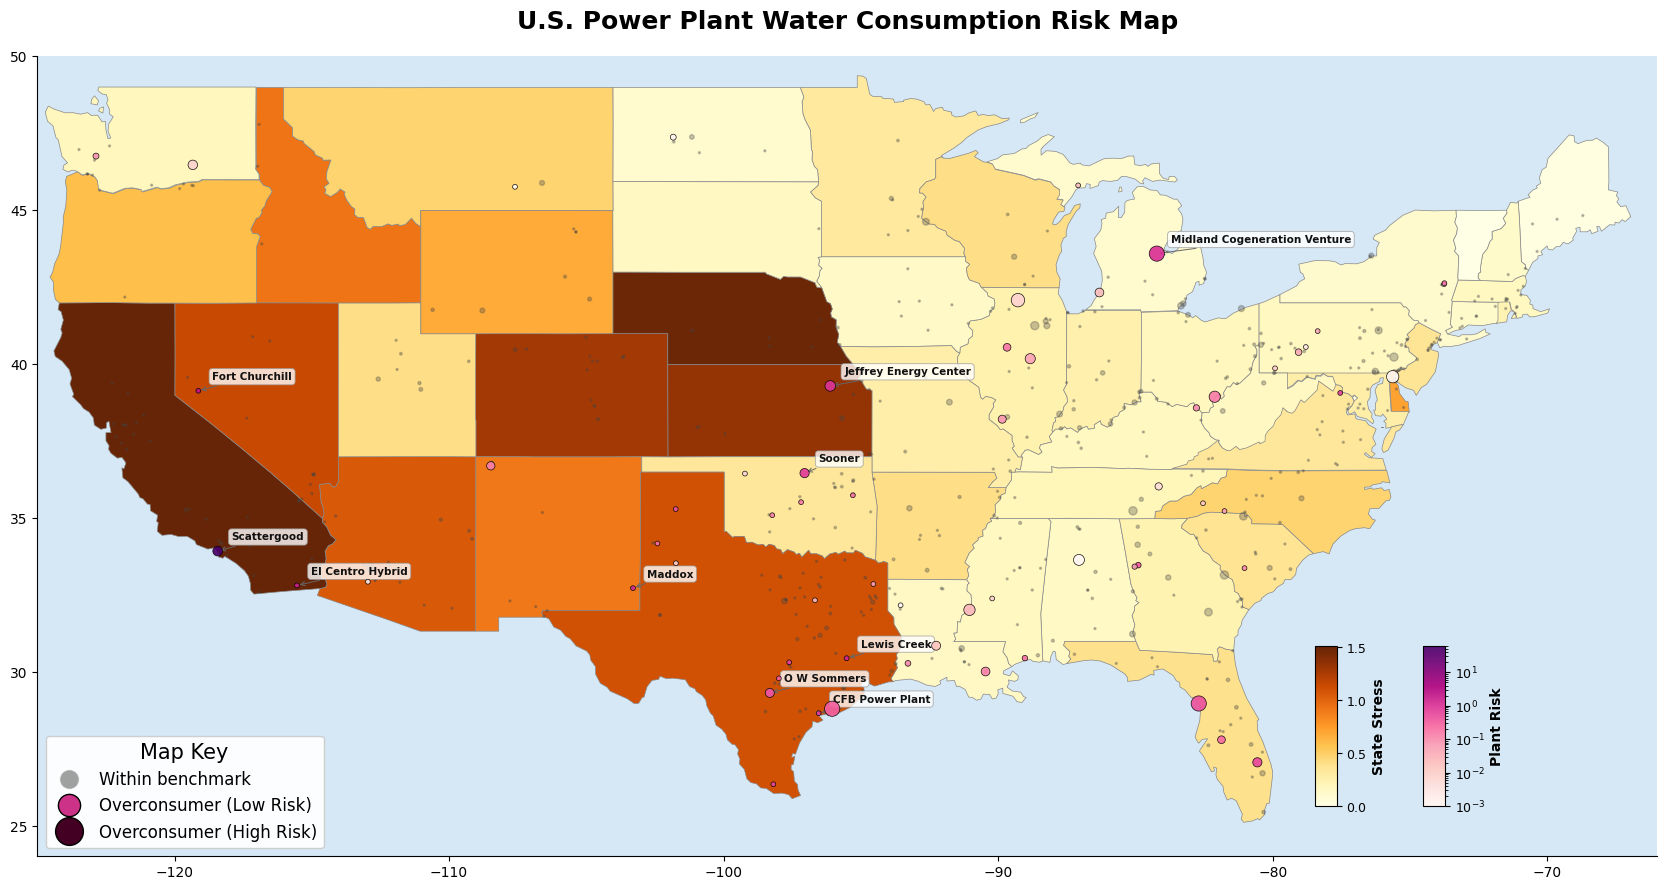

In [45]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon

# ── 1. Build state-level mean bws_raw from plant data ───────────────
state_bws = (df.groupby('state')['bws_raw']
               .mean()
               .reset_index()
               .rename(columns={'bws_raw': 'mean_bws'}))

STATE_NAME_TO_ABBR = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT',
    'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME',
    'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI',
    'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM',
    'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND',
    'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC',
}

bws_lookup = dict(zip(state_bws['state'], state_bws['mean_bws']))

# ── 2. Colour scale for state choropleth ─────────────────────
bws_cmap = plt.cm.YlOrBr
bws_vals = list(bws_lookup.values())
bws_norm = mcolors.Normalize(vmin=0, vmax=max(bws_vals) if bws_vals else 1)

def bws_colour(abbr):
    v = bws_lookup.get(abbr, 0)
    return bws_cmap(bws_norm(v))

# ── 3. Plant data: CONUS only ─────
map_df = df.sort_values('year').groupby('plant_code').last().reset_index()
map_df = map_df[
    map_df['LON'].between(-130, -60) &
    map_df['LAT'].between(24, 50)
].copy()

# ── 4. Figure setup ─────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_facecolor('#d6e8f5')

# Position the main map
ax.set_position([0.05, 0.1, 0.9, 0.8])

# Helper for rings
def extract_rings(geometry):
    rings = []
    if geometry['type'] == 'Polygon':
        rings.extend(geometry['coordinates'])
    elif geometry['type'] == 'MultiPolygon':
        for poly in geometry['coordinates']:
            rings.extend(poly)
    return rings

# ── 6. Draw states ───
for feature in states_geojson['features']:
    full_name = feature['properties'].get('name', '')
    abbr      = STATE_NAME_TO_ABBR.get(full_name, '')
    fc        = bws_colour(abbr)
    rings = extract_rings(feature['geometry'])
    state_patches = []
    for ring in rings:
        coords = np.array(ring)
        if coords.ndim == 2 and len(coords) > 2:
            if -130 < coords[:, 0].mean() < -60:
                state_patches.append(MplPolygon(coords, closed=True))
    if state_patches:
        pc = PatchCollection(state_patches, facecolor=fc, edgecolor='#888888', linewidth=0.5, zorder=1)
        ax.add_collection(pc)

# ── 7. Plants ───────
safe = map_df[map_df['risk_score'] == 0]
ax.scatter(safe['LON'], safe['LAT'], s=np.clip(safe['consumption_ML'] / 1500, 2, 35), color='#444444', alpha=0.30, zorder=2, label='Within benchmark')

risk = map_df[map_df['risk_score'] > 0].copy()
if len(risk) > 0:
    plant_cmap = plt.cm.RdPu
    plant_norm = mcolors.LogNorm(vmin=max(risk['risk_score'].min(), 0.001), vmax=risk['risk_score'].max())
    sc = ax.scatter(risk['LON'], risk['LAT'], s=np.clip(risk['consumption_ML'] / 600, 12, 120), c=risk['risk_score'], cmap=plant_cmap, norm=plant_norm, alpha=0.92, zorder=4, edgecolors='black', linewidths=0.5, label='Overconsumer plant')

# ── 8. Colorbars (Now positioned inside the blue ocean area to avoid edges) ──
sm_bws = plt.cm.ScalarMappable(cmap=bws_cmap, norm=bws_norm)
sm_bws.set_array([])

# Adjusted positions to be well within the axes plot area
cbar_bottom = 0.15
cbar_height = 0.16
cbar_width = 0.012

# State Stress Colorbar (shifted left to stay in ocean)
cbar_bws_ax = fig.add_axes([0.76, cbar_bottom, cbar_width, cbar_height])
cbar_bws = plt.colorbar(sm_bws, cax=cbar_bws_ax)
cbar_bws.set_label('State Stress', fontsize=10, fontweight='bold')
cbar_bws.ax.tick_params(labelsize=9)

# Plant Risk Colorbar (shifted left to stay in ocean)
cbar_plant_ax = fig.add_axes([0.82, cbar_bottom, cbar_width, cbar_height])
cbar_plant = plt.colorbar(sc, cax=cbar_plant_ax)
cbar_plant.set_label('Plant Risk', fontsize=10, fontweight='bold')
cbar_plant.ax.tick_params(labelsize=9)

# ── 10. Annotation & Legend ──────────────
top10 = map_df.nlargest(10, 'risk_score')
for _, row in top10.iterrows():
    ax.annotate(row['plant_name'].split('(')[0].strip(), xy=(row['LON'], row['LAT']), xytext=(10, 8), textcoords='offset points', fontsize=7.5, color='#111111', fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='#999999', lw=0.6), arrowprops=dict(arrowstyle='->', color='#666666', lw=0.7))

# Increased markersize and font for the bottom-left key
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444', markersize=14, alpha=0.5, label='Within benchmark'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#cc3388', markersize=16, markeredgecolor='black', label='Overconsumer (Low Risk)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#440022', markersize=20, markeredgecolor='black', label='Overconsumer (High Risk)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, framealpha=0.95, title='Map Key', title_fontsize=15)

# ── 12. Final ──────────────────
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title('U.S. Power Plant Water Consumption Risk Map', fontsize=18, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('risk_map_v4.png', dpi=200, bbox_inches='tight')
plt.show()

### Interpretation: Spatial Risk Map

This map is the **central visualization** of the research. Each dot represents a power plant:

- **Grey dots** = plants operating within their predicted consumption ceiling (the "normal" ones)
- **Colored dots (yellow to red)** = overconsumers, with color intensity showing the **composite risk score**

**The risk score combines two factors:**
1. **How far above the ceiling** the plant consumes (excess ratio) — a plant 200% over its ceiling is worse than one 10% over
2. **How water-stressed the watershed is** (`bws_raw` — baseline water stress) — overconsumption in drought-prone Nevada is a bigger problem than in water-rich Louisiana

**What to highlight in your presentation:**
- Large red dots in the South/Southwest indicate high-risk plants in water-stressed areas — these are the priority targets for policy intervention
- The labeled plants (top 10 risk scores) are the most problematic: large overconsumers in stressed watersheds
- Many grey dots show that most plants operate within expected ranges — the overconsumers are a distinct minority that can be specifically targeted

## 4. Top 20 Highest-Risk Plant-Years

In [36]:
top20 = (df[df['risk_score'] > 0]
         .nlargest(20, 'risk_score')
         [['plant_name', 'state', 'year', 'consumption_ML',
           'predicted_ceiling_90', 'excess_pct_90', 'bws_raw', 'risk_score',
           'cooling_category', 'primary_fuel']]
         .copy())
top20['excess_pct_90'] = top20['excess_pct_90'].map('{:.1%}'.format)
top20['consumption_ML'] = top20['consumption_ML'].map('{:,.1f}'.format)
top20['predicted_ceiling_90'] = top20['predicted_ceiling_90'].map('{:,.1f}'.format)
top20['risk_score'] = top20['risk_score'].round(3)
top20['bws_raw'] = top20['bws_raw'].round(3)
print('Top 20 highest-risk plant-years:')
print(top20.to_string(index=False))

Top 20 highest-risk plant-years:
            plant_name state  year consumption_ML predicted_ceiling_90 excess_pct_90  bws_raw  risk_score cooling_category primary_fuel
           Scattergood    CA  2024       29,262.0                717.5       3978.2%    1.510      60.056       Dry-Hybrid           NG
           Scattergood    CA  2023       31,897.5                812.0       3828.4%    1.510      57.795       Dry-Hybrid           NG
           Scattergood    CA  2022       36,135.5                977.6       3596.3%    1.510      54.292       Dry-Hybrid           NG
           Scattergood    CA  2021       35,012.8                957.8       3555.4%    1.510      53.674       Dry-Hybrid           NG
      El Centro Hybrid    CA  2023        9,171.9              2,552.9        259.3%    1.510       3.914           Closed           NG
        Fort Churchill    NV  2021        3,984.8              1,024.3        289.0%    1.147       3.316           Closed           NG
        Fort Ch

### Interpretation: Top 20 Risk Table

This table ranks the most problematic plant-year observations. Key columns to discuss:

- **`excess_pct_90`**: How far above the q=0.90 ceiling — e.g., "250%" means the plant consumed 2.5x more water than the ceiling predicts
- **`bws_raw`**: Watershed stress score (0 to 5 scale) — higher = scarcer water
- **`risk_score`**: Product of excess ratio and stress — the composite metric

**Pattern to highlight:** Many top-risk plants are coal or nuclear facilities with **Open (once-through) cooling** in water-stressed regions. This directly motivates the counterfactual analysis in Notebook 04 — what if these plants switched to Closed cooling?

## 5. Mean Risk Score by State (Top 15)

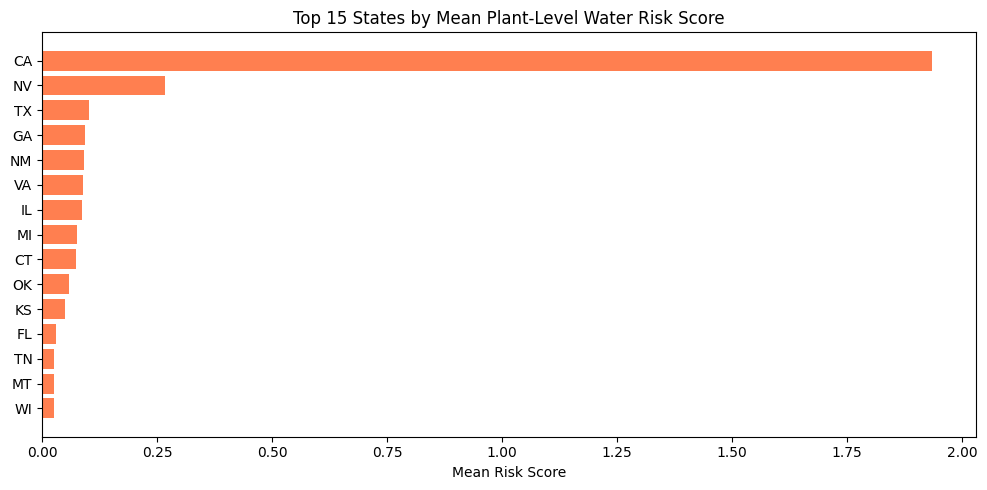

       mean_risk  total_consumption_ML n_overconsumers  n_plants
state                                                           
CA         1.933            271143.075               7        32
NV         0.268             30003.697               4        12
TX         0.102           1565109.744              44        84
GA         0.094            763324.682               7        15
NM         0.090            124171.445               8         9
VA         0.088             73594.094               7        15
IL         0.086           1174289.282               9        16
MI         0.075            534791.963               9        14
CT         0.073             34221.288               1         6
OK         0.059            277813.950              13        21
KS         0.049            227949.289               2         8
FL         0.031            632867.026              11        23
TN         0.027            277605.987               5         7
MT         0.026         

In [37]:
state_risk = (df.groupby('state')
              .agg(mean_risk=('risk_score', 'mean'),
                   total_consumption_ML=('consumption_ML', 'sum'),
                   n_overconsumers=('overconsumer_90', 'sum'),
                   n_plants=('plant_code', 'nunique'))
              .sort_values('mean_risk', ascending=False)
              .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(state_risk.index[::-1], state_risk['mean_risk'][::-1], color='coral')
ax.set_xlabel('Mean Risk Score')
ax.set_title('Top 15 States by Mean Plant-Level Water Risk Score')
plt.tight_layout()
plt.show()

print(state_risk.round(3).to_string())

## 6. Risk by Cooling Technology

Overconsumption risk is concentrated in certain cooling technologies. Open (once-through) cooling plants are most vulnerable to overconsumption relative to their benchmark.

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/risk_by_cooling.png'

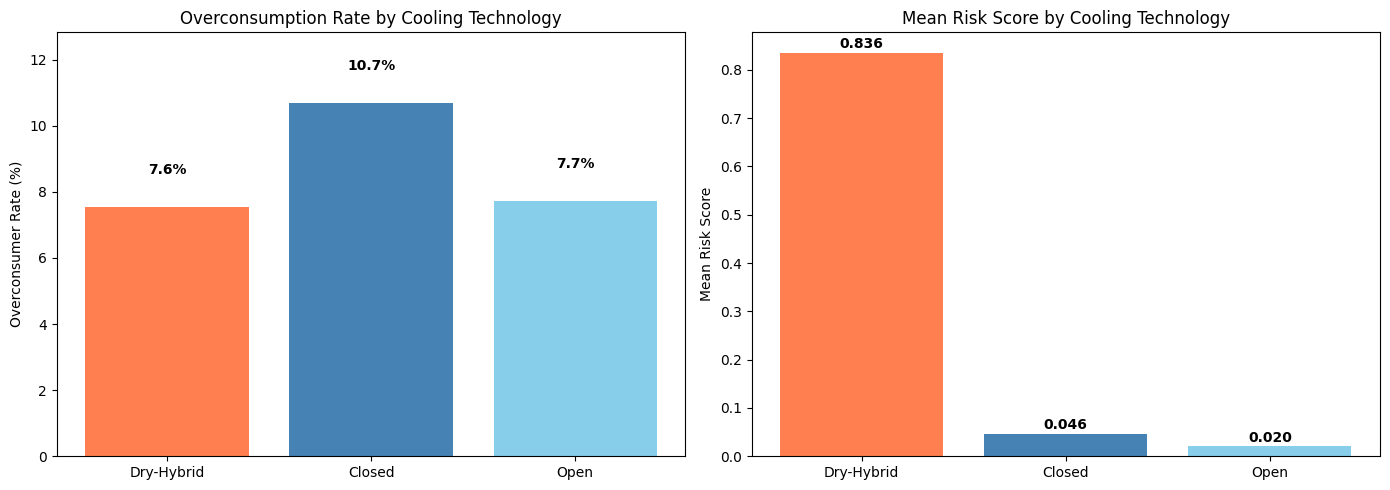

In [38]:
cooling_risk = (df.groupby('cooling_category')
                .agg(n_plant_years=('plant_code', 'count'),
                     n_overconsumers=('overconsumer_90', 'sum'),
                     overconsumer_rate=('overconsumer_90', 'mean'),
                     mean_risk_score=('risk_score', 'mean'),
                     total_consumption_ML=('consumption_ML', 'sum'),
                     n_high_risk=('risk_score', lambda x: (x > 0).sum()))
                .sort_values('mean_risk_score', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overconsumer rate by cooling
ax = axes[0]
ax.bar(cooling_risk.index, cooling_risk['overconsumer_rate'] * 100, color=['coral', 'steelblue', 'skyblue'])
ax.set_ylabel('Overconsumer Rate (%)')
ax.set_title('Overconsumption Rate by Cooling Technology')
ax.set_ylim(0, max(cooling_risk['overconsumer_rate'] * 100) * 1.2)
for i, v in enumerate(cooling_risk['overconsumer_rate'] * 100):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Mean risk score by cooling
ax = axes[1]
ax.bar(cooling_risk.index, cooling_risk['mean_risk_score'], color=['coral', 'steelblue', 'skyblue'])
ax.set_ylabel('Mean Risk Score')
ax.set_title('Mean Risk Score by Cooling Technology')
for i, v in enumerate(cooling_risk['mean_risk_score']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_DIR / 'risk_by_cooling.png', dpi=150, bbox_inches='tight')
plt.show()

print('Risk by Cooling Category:')
print(cooling_risk.round(3).to_string())


## 7. Overconsumption vs Watershed Stress Relationship

Check whether plants that exceed their benchmark tend to be located in more water-stressed watersheds (indicating potential policy concern).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: overconsumption vs stress (log scale)
df_nonzero = df[(df['bws_raw'] > 0) & (df['excess_pct_90'].notna())].copy()
colors = ['coral' if x else 'steelblue' for x in df_nonzero['overconsumer_90'].tolist()]
ax = axes[0]
ax.scatter(df_nonzero['bws_raw'], df_nonzero['excess_pct_90'], alpha=0.3, s=10, c=colors)
ax.set_xscale('log')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Watershed Stress (bws_raw, log scale)')
ax.set_ylabel('Excess Consumption (% above ceiling)')
ax.set_title('Overconsumption vs Watershed Stress')
ax.grid(True, alpha=0.3)

# Correlation by group
ax = axes[1]
overconsumer_mask = df_nonzero['overconsumer_90'].astype(bool)
stress_overconsumer = df_nonzero[overconsumer_mask]['bws_raw'].values
stress_within = df_nonzero[~overconsumer_mask]['bws_raw'].values
box_data = [stress_within, stress_overconsumer]
bp = ax.boxplot(box_data, tick_labels=['Within Ceiling', 'Overconsumer'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax.set_ylabel('Watershed Stress (bws_raw)')
ax.set_title('Water Stress Distribution:\nOverconsumers vs Within-Ceiling Plants')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(DATA_DIR / 'stress_vs_overconsumption.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print('=== Watershed Stress Analysis ===')
overconsumer_stress = df[df['overconsumer_90'].astype(bool)]['bws_raw'].mean()
within_stress = df[~df['overconsumer_90'].astype(bool)]['bws_raw'].mean()
print(f'Mean bws_raw (overconsumers):     {overconsumer_stress:.3f}')
print(f'Mean bws_raw (within ceiling):    {within_stress:.3f}')
print(f'Overconsumers in high-stress (bws > 0.5): {((df["overconsumer_90"].astype(bool)) & (df["bws_raw"] > 0.5)).sum()} plants')
print(f'Plants with risk_score > 0: {(df["risk_score"] > 0).sum():,}')

# Correlation
corr = df_nonzero[['excess_pct_90', 'bws_raw']].corr().iloc[0, 1]
print(f'\nCorrelation (excess % vs water stress): {corr:.3f}')

## 8. Key Findings — Risk Mapping Summary

This spatial analysis reveals three critical patterns:

1. **Geographic Concentration**: High-risk plants cluster in specific regions (Texas, the Southeast, and the Great Lakes), where both overconsumption and water stress are elevated.

2. **Technology Vulnerability**: Open (once-through) cooling plants show systematically higher overconsumption rates and risk scores. They are the prime candidates for policy intervention (switching to closed-loop or hybrid cooling).

3. **Stress-Consumption Alignment**: Overconsumers tend to be located in more water-stressed watersheds (higher bws_raw scores), meaning the plants driving the largest deviations from benchmarks are precisely where water scarcity is a concern. This validates the composite risk score as a policy-relevant metric.

**Next Step**: Aggregate to state level for policy recommendations (Notebook 04).